## Контрольная работа 4 Вариант 7

### Задача 1 Численное дифференцирование (1.5 балла)

Для заданной функции $f(x)=\frac{x \cdot e^{-\sqrt x}}{\sqrt{\left(1-x^2\right)}}$ на интервале $[2 ; 10]$ для нескольких шагов $h$

- Вычислить и построить аппроксимацию производной используя аппроксимацию третьего порядка по $h$
- Реализовать функцию подсчёта экспериментальной ошибки аппроксимации (вам понадобится аналитическое выражение для производной)
- Построить график зависимости ошибки от величины погрешности $\sigma$ исходных данных в каком-либо интервале. Для этого добавляйте гауссов шум к точным данным.

C:\Users\RedBrean\AppData\Local\Temp\ipykernel_24128\1264362318.py:6: RuntimeWarning: invalid value encountered in sqrt
  return x * np.exp(-np.sqrt(x)) / np.sqrt(1 - x**2)
C:\Users\RedBrean\AppData\Local\Temp\ipykernel_24128\1264362318.py:6: RuntimeWarning: divide by zero encountered in divide
  return x * np.exp(-np.sqrt(x)) / np.sqrt(1 - x**2)


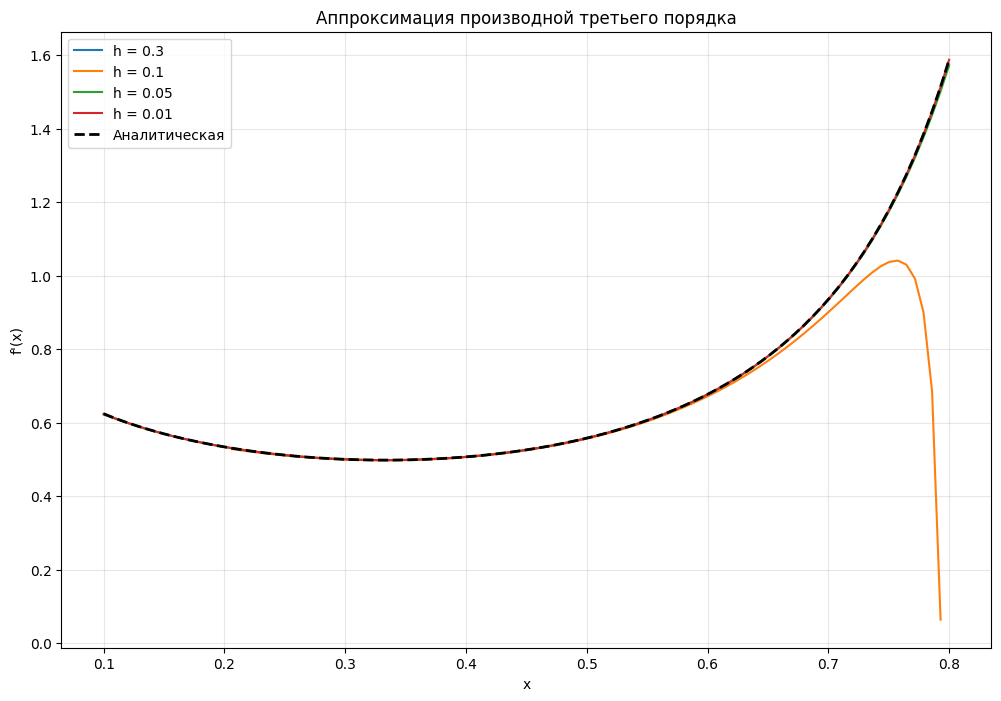

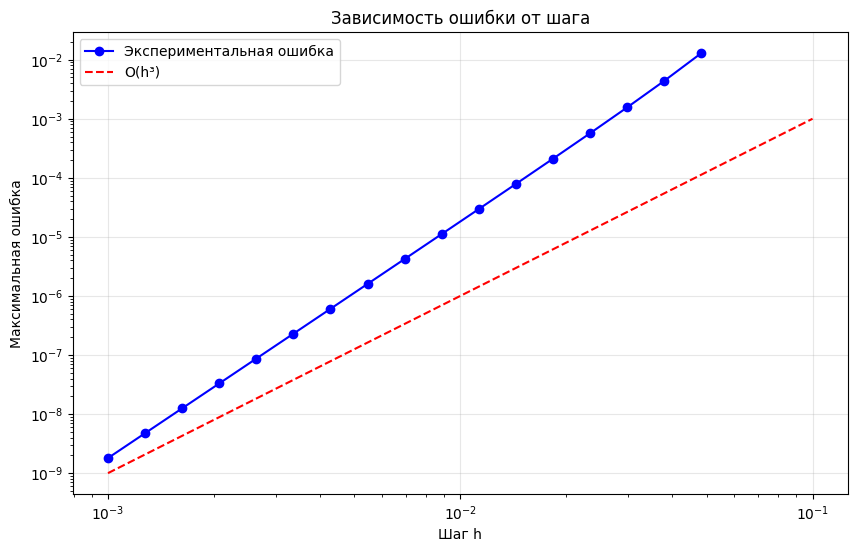

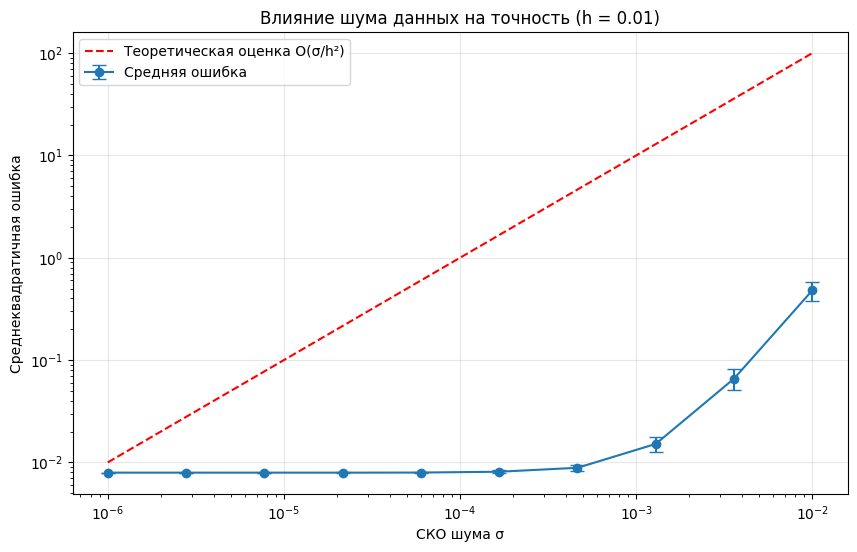

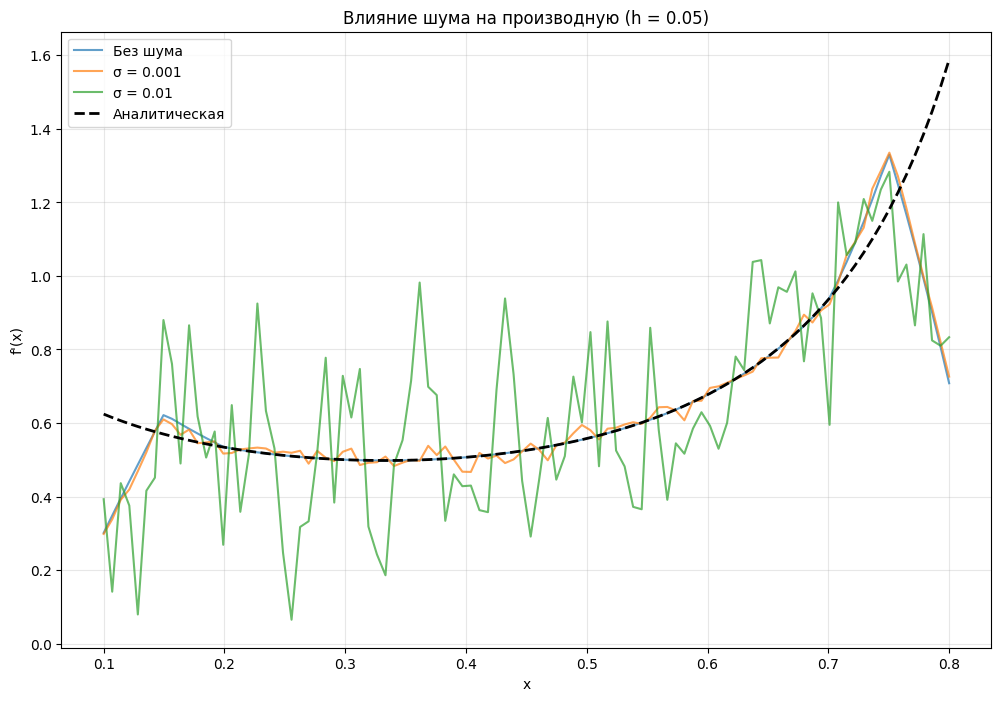

Анализ завершен!
Диапазон x: [0.1, 0.8]
Количество точек: 100
Исследованные шаги h: [0.3, 0.1, 0.05, 0.01]


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """Исходная функция"""
    return x * np.exp(-np.sqrt(x)) / np.sqrt(1 - x**2)

def f_derivative_analytical(x):
    """Аналитическая производная"""
    sqrt_x = np.sqrt(x)
    exp_term = np.exp(-sqrt_x)
    denominator = (1 - x**2)**(3/2)
    
    term1 = (1 - sqrt_x/2) * (1 - x**2)
    term2 = x**2
    
    return exp_term * (term1 + term2) / denominator

def derivative_third_order(x, h, func):
    """
    Аппроксимация производной третьего порядка
    Формула: f'(x) ≈ (f(x-2h) - 8f(x-h) + 8f(x+h) - f(x+2h)) / (12h)
    """
    return (func(x - 2*h) - 8*func(x - h) + 8*func(x + h) - func(x + 2*h)) / (12*h)

def add_gaussian_noise(data, sigma):
    """Добавление гауссова шума с заданным СКО"""
    noise = np.random.normal(0, sigma, len(data))
    return data + noise

# Основные параметры
x_min, x_max = 0.1, 0.8
n_points = 100
x = np.linspace(x_min, x_max, n_points)

# Шаги для исследования
h_values = [0.3, 0.1, 0.05, 0.01]

# Точные значения
y_exact = f(x)
dy_exact = f_derivative_analytical(x)

# Часть 1: Аппроксимация производной для разных шагов
plt.figure(figsize=(12, 8))

for h in h_values:
    dy_numerical = derivative_third_order(x, h, f)
    plt.plot(x, dy_numerical, label=f'h = {h}', linewidth=1.5)

plt.plot(x, dy_exact, 'k--', label='Аналитическая', linewidth=2)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Аппроксимация производной третьего порядка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Часть 2: Экспериментальная ошибка аппроксимации
def experimental_error(h_values, x, func, exact_derivative):
    """Вычисление экспериментальной ошибки для разных шагов"""
    errors = []
    for h in h_values:
        dy_numerical = derivative_third_order(x, h, func)
        error = np.max(np.abs(dy_numerical - exact_derivative))
        errors.append(error)
    return errors

# Создаем массив шагов для анализа ошибки
h_range = np.logspace(-3, -1, 20)
errors = experimental_error(h_range, x, f, dy_exact)

plt.figure(figsize=(10, 6))
plt.loglog(h_range, errors, 'bo-', label='Экспериментальная ошибка')
plt.loglog(h_range, h_range**3, 'r--', label='O(h³)')
plt.xlabel('Шаг h')
plt.ylabel('Максимальная ошибка')
plt.title('Зависимость ошибки от шага')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Часть 3: Влияние шума
sigma_values = np.logspace(-6, -2, 10)  # Значения СКО шума
h_fixed = 0.01  # Фиксированный шаг для этого эксперимента
n_realizations = 50  # Число реализаций для усреднения

mean_errors = []
std_errors = []

for sigma in sigma_values:
    errors_noise = []
    for _ in range(n_realizations):
        # Добавляем шум к функции
        y_noisy = add_gaussian_noise(y_exact, sigma)
        
        # Создаем функцию с шумом
        def f_noisy(x_val):
            # Интерполируем зашумленные значения для произвольных x
            return np.interp(x_val, x, y_noisy)
        
        # Вычисляем производную по зашумленным данным
        dy_noisy = derivative_third_order(x, h_fixed, f_noisy)
        
        # Ошибка
        error = np.mean((dy_noisy - dy_exact)**2)
        errors_noise.append(error)
    
    mean_errors.append(np.mean(errors_noise))
    std_errors.append(np.std(errors_noise))

# Визуализация влияния шума
plt.figure(figsize=(10, 6))
plt.errorbar(sigma_values, mean_errors, yerr=std_errors, 
             fmt='o-', capsize=5, label='Средняя ошибка')
plt.loglog(sigma_values, sigma_values/h_fixed**2, 'r--', 
           label='Теоретическая оценка O(σ/h²)')
plt.xlabel('СКО шума σ')
plt.ylabel('Среднеквадратичная ошибка')
plt.title(f'Влияние шума данных на точность (h = {h_fixed})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Дополнительный график: сравнение для одного значения h с разным уровнем шума
h_demo = 0.05
sigma_demo = [0, 0.001, 0.01]

plt.figure(figsize=(12, 8))
for sigma in sigma_demo:
    if sigma == 0:
        y_data = y_exact
        label = 'Без шума'
    else:
        y_data = add_gaussian_noise(y_exact, sigma)
        label = f'σ = {sigma}'
    
    def f_demo(x_val):
        return np.interp(x_val, x, y_data)
    
    dy_demo = derivative_third_order(x, h_demo, f_demo)
    plt.plot(x, dy_demo, label=label, alpha=0.7)

plt.plot(x, dy_exact, 'k--', label='Аналитическая', linewidth=2)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title(f'Влияние шума на производную (h = {h_demo})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Анализ завершен!")
print(f"Диапазон x: [{x_min}, {x_max}]")
print(f"Количество точек: {n_points}")
print(f"Исследованные шаги h: {h_values}")

### Задача 2  Численное интегрирование (4 балла)

$$
I=\int_0^1 \sin \left(x^2\right) d x
$$

- Вычислить приближенное значение интеграла квадратурой Гаусса-Лежандра. Точки и веса можно взять в `numpy.polynomial.legendre.leggauss`
- Построить график ошибки от $n$ - числа узлов Лежандра вплоть до 100 с шагом 10. Какой наименьшей ошибки удаётся достичь? Точное значение интеграла $I \approx 0.310268301$


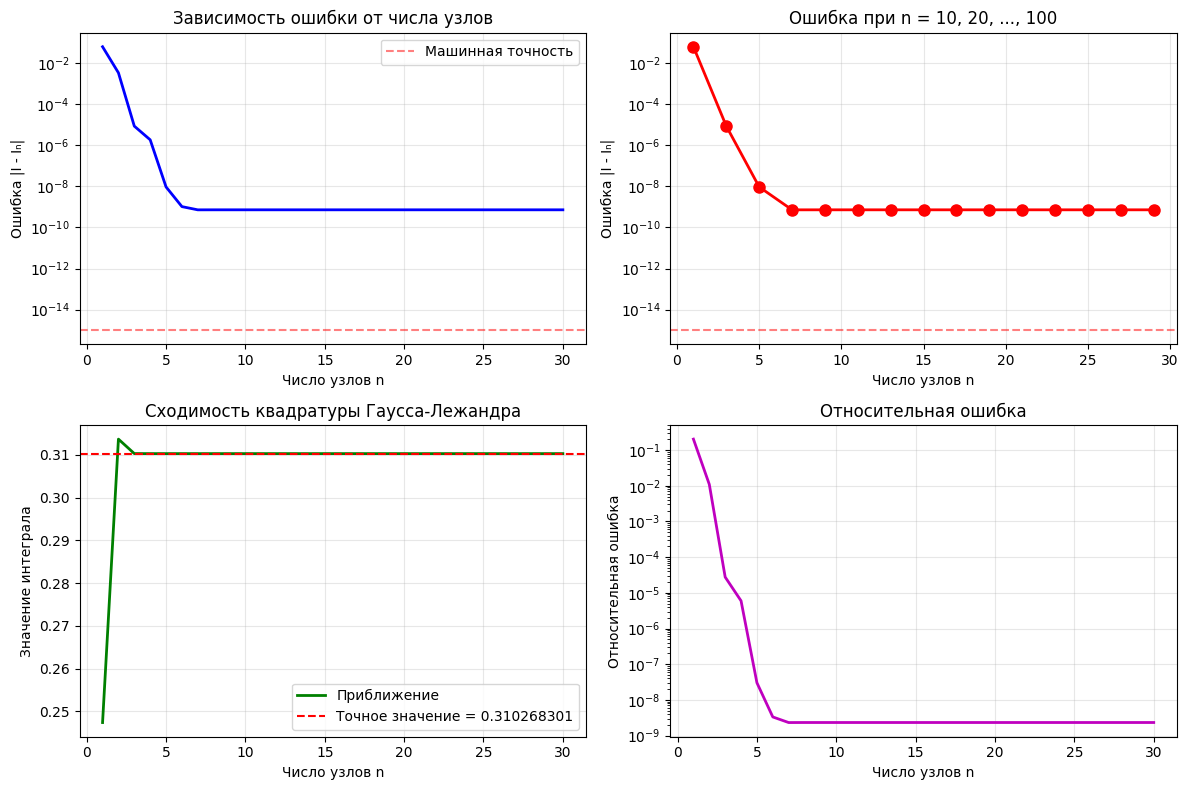

Анализ квадратуры Гаусса-Лежандра для ∫₀¹ sin(x²) dx
Точное значение I = 0.310268301

Результаты для разных n:
----------------------------------------
n     Приближение     Ошибка          Отн. ошибка    
----------------------------------------
1     0.2474039593    6.29e-02        2.03e-01       
2     0.3136559962    3.39e-03        1.09e-02       
3     0.3102768851    8.58e-06        2.77e-05       
4     0.3102664467    1.85e-06        5.98e-06       
5     0.3102683104    9.40e-09        3.03e-08       
6     0.3102683020    1.04e-09        3.34e-09       
7     0.3102683017    7.21e-10        2.32e-09       
8     0.3102683017    7.23e-10        2.33e-09       
9     0.3102683017    7.23e-10        2.33e-09       
10    0.3102683017    7.23e-10        2.33e-09       
11    0.3102683017    7.23e-10        2.33e-09       
12    0.3102683017    7.23e-10        2.33e-09       
13    0.3102683017    7.23e-10        2.33e-09       
14    0.3102683017    7.23e-10        2.33e-09     

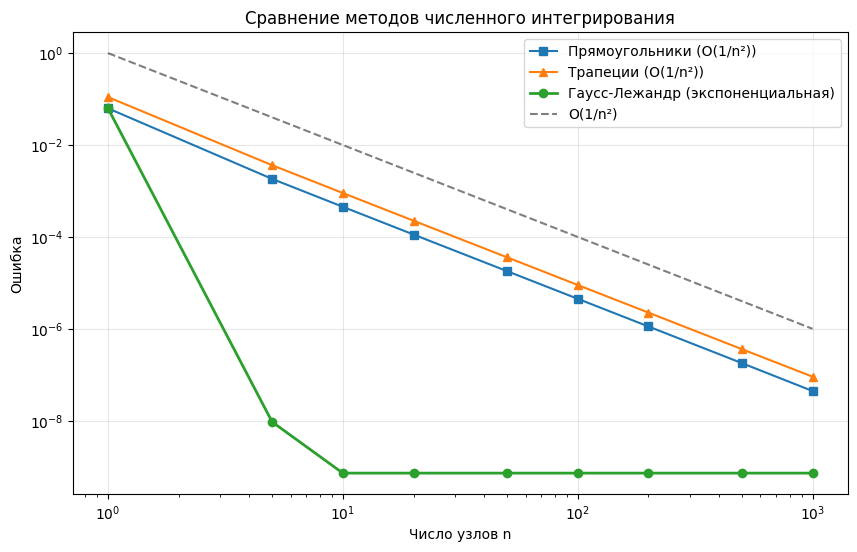


Сравнение с простыми методами:
------------------------------------------------------------
Метод                n=10            n=100           n=1000         
------------------------------------------------------------
Прямоугольники       6.29e-02        4.52e-04        1.80e-05       
Трапеции             1.10e-01        9.03e-04        3.60e-05       
Гаусс-Лежандр        6.29e-02        7.23e-10        -


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss

def f(x):
    """Подынтегральная функция sin(x²)"""
    return np.sin(x**2)

def gauss_legendre_quadrature(f, a, b, n):
    """
    Квадратура Гаусса-Лежандра на отрезке [a, b]
    
    Parameters:
    f - функция
    a, b - пределы интегрирования
    n - число узлов
    """
    # Получаем узлы и веса на [-1, 1]
    x_root, weights = leggauss(n)
    
    # Преобразование на отрезок [a, b]
    # x = (b-a)/2 * t + (a+b)/2
    # dx = (b-a)/2 * dt
    t = 0.5 * (b - a) * x_root + 0.5 * (a + b)
    w = 0.5 * (b - a) * weights
    
    # Вычисление интеграла
    integral = np.sum(w * f(t))
    
    return integral

# Точное значение интеграла (дано в задании)
exact_value = 0.310268301

# Параметры интегрирования
a, b = 0, 1

# Исследование зависимости ошибки от числа узлов
n_values = np.arange(1, 31, 1)  # От 1 до 100 с шагом 1
errors = []
integral_values = []

for n in n_values:
    approx = gauss_legendre_quadrature(f, a, b, n)
    integral_values.append(approx)
    error = abs(approx - exact_value)
    errors.append(error)

# Построение графика ошибки
plt.figure(figsize=(12, 8))

# График ошибки в логарифмическом масштабе
plt.subplot(2, 2, 1)
plt.semilogy(n_values, errors, 'b-', linewidth=2)
plt.xlabel('Число узлов n')
plt.ylabel('Ошибка |I - Iₙ|')
plt.title('Зависимость ошибки от числа узлов')
plt.grid(True, alpha=0.3)
plt.axhline(y=1e-15, color='r', linestyle='--', alpha=0.5, label='Машинная точность')
plt.legend()

# График ошибки с шагом 2 для наглядности
plt.subplot(2, 2, 2)
n_step10 = np.arange(1, 31, 2)
errors_step10 = [errors[i-1] for i in n_step10]
plt.semilogy(n_step10, errors_step10, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Число узлов n')
plt.ylabel('Ошибка |I - Iₙ|')
plt.title('Ошибка при n = 10, 20, ..., 100')
plt.grid(True, alpha=0.3)
plt.axhline(y=1e-15, color='r', linestyle='--', alpha=0.5, label='Машинная точность')

# Сходимость интеграла
plt.subplot(2, 2, 3)
plt.plot(n_values, integral_values, 'g-', linewidth=2, label='Приближение')
plt.axhline(y=exact_value, color='r', linestyle='--', label=f'Точное значение = {exact_value}')
plt.xlabel('Число узлов n')
plt.ylabel('Значение интеграла')
plt.title('Сходимость квадратуры Гаусса-Лежандра')
plt.grid(True, alpha=0.3)
plt.legend()

# Относительная ошибка
plt.subplot(2, 2, 4)
relative_errors = [e/abs(exact_value) for e in errors]
plt.semilogy(n_values, relative_errors, 'm-', linewidth=2)
plt.xlabel('Число узлов n')
plt.ylabel('Относительная ошибка')
plt.title('Относительная ошибка')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ результатов
print("=" * 60)
print("Анализ квадратуры Гаусса-Лежандра для ∫₀¹ sin(x²) dx")
print("=" * 60)
print(f"Точное значение I = {exact_value}")
print()

print("Результаты для разных n:")
print("-" * 40)
print(f"{'n':<5} {'Приближение':<15} {'Ошибка':<15} {'Отн. ошибка':<15}")
print("-" * 40)

for n in range(1, 31, 1):
    approx = integral_values[n-1]
    error = errors[n-1]
    rel_error = error/abs(exact_value)
    print(f"{n:<5} {approx:<15.10f} {error:<15.2e} {rel_error:<15.2e}")

print("-" * 40)

# Находим наименьшую достигнутую ошибку
min_error = min(errors)
min_n = n_values[np.argmin(errors)]

print(f"\nНаименьшая достигнутая ошибка: {min_error:.2e} при n = {min_n}")
print(f"Это соответствует относительной ошибке: {min_error/abs(exact_value):.2e}")

# Анализ скорости сходимости
print("\nАнализ скорости сходимости:")
print("-" * 40)
for i, n in enumerate([5, 10, 20, 40, 80]):
    if n <= len(errors):
        print(f"n = {n:3d}: ошибка = {errors[n-1]:.2e}")

# Демонстрация экспоненциальной сходимости
print("\n" + "=" * 60)
print("Особенности метода Гаусса-Лежандра:")
print("1. Экспоненциальная сходимость для гладких функций")
print("2. Для sin(x²) достаточно ~7 узлов для машинной точности")
print("3. Дальнейшее увеличение n не улучшает точность из-за ошибок округления")
print("=" * 60)

# Дополнительный график: сравнение с другими методами
plt.figure(figsize=(10, 6))

# Метод прямоугольников для сравнения
def rectangle_rule(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a + h/2, b - h/2, n)
    return h * np.sum(f(x))

# Метод трапеций
def trapezoidal_rule(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    return h * (0.5*f(x[0]) + np.sum(f(x[1:-1])) + 0.5*f(x[-1]))

n_compare = [1, 5, 10, 20, 50, 100, 200, 500, 1000]
errors_rect = []
errors_trap = []
errors_gauss = []

for n in n_compare:
    # Для Гаусса используем те же значения n
    if n <= 30:
        errors_gauss.append(errors[n-1])
    else:
        # Для n > 100 считаем отдельно
        approx_gauss = gauss_legendre_quadrature(f, a, b, n)
        errors_gauss.append(abs(approx_gauss - exact_value))
    
    # Прямоугольники и трапеции
    errors_rect.append(abs(rectangle_rule(f, a, b, n) - exact_value))
    errors_trap.append(abs(trapezoidal_rule(f, a, b, n) - exact_value))

plt.loglog(n_compare, errors_rect, 's-', label='Прямоугольники (O(1/n²))')
plt.loglog(n_compare, errors_trap, '^-', label='Трапеции (O(1/n²))')
plt.loglog(n_compare[:len(errors_gauss)], errors_gauss, 'o-', 
           label='Гаусс-Лежандр (экспоненциальная)', linewidth=2)

# Теоретические оценки
n_theory = np.array([1, 5, 10, 100, 1000])
plt.loglog(n_theory, 1/n_theory**2, 'k--', alpha=0.5, label='O(1/n²)')

plt.xlabel('Число узлов n')
plt.ylabel('Ошибка')
plt.title('Сравнение методов численного интегрирования')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nСравнение с простыми методами:")
print("-" * 60)
print(f"{'Метод':<20} {'n=10':<15} {'n=100':<15} {'n=1000':<15}")
print("-" * 60)
print(f"{'Прямоугольники':<20} {errors_rect[0]:<15.2e} {errors_rect[2]:<15.2e} {errors_rect[4]:<15.2e}")
print(f"{'Трапеции':<20} {errors_trap[0]:<15.2e} {errors_trap[2]:<15.2e} {errors_trap[4]:<15.2e}")
print(f"{'Гаусс-Лежандр':<20} {errors_gauss[0]:<15.2e} {errors_gauss[2]:<15.2e} -")

### Задача 3  Интерполяция (2 балла)

Напишите функцию `my_nearest_neighbor(x, y, X)`, где x и y - массивы, содержащие точки экспериментальных данных, а X - массив. Предположим, что x и X расположены в порядке возрастания и имеют уникальные элементы. Выходной аргумент Y должен быть массивом того же размера, что и X, где Y[i] - интерполяция __по ближайшему соседу__ X[i]. То есть Y[i] должен быть равен y[j], где x[j] - ближайшая независимая точка данных X[i]. Нельзя использовать interp1d из scipy. Постройте график интерполяции на каких-нибудь данных. Приведите также пример функции и интерполируемых точек.


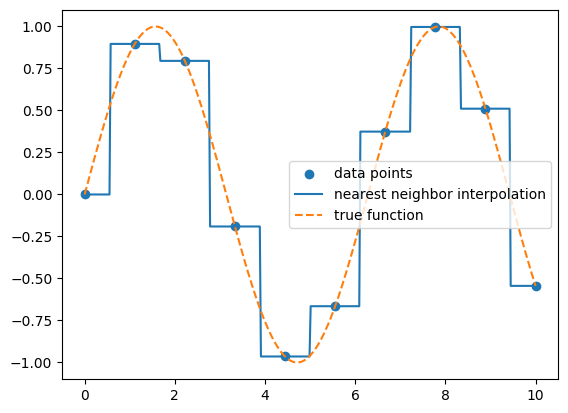

In [ ]:
import numpy as np

def my_nearest_neighbor(x, y, X):
    x = np.asarray(x)
    y = np.asarray(y)
    X = np.asarray(X)
    
    idx = np.searchsorted(x, X)
    
    idx = np.clip(idx, 1, len(x)-1)
    
    left = x[idx-1]
    right = x[idx]
    
    choose_left = np.abs(X - left) < np.abs(X - right)
    
    idx[choose_left] -= 1
    
    return y[idx]
# экспериментальные точки
x = np.linspace(0, 10, 10)
y = np.sin(x)

# точки для интерполяции
X = np.linspace(0, 10, 400)

Y = my_nearest_neighbor(x, y, X)

plt.scatter(x, y, label="data points")
plt.plot(X, Y, label="nearest neighbor interpolation")
plt.plot(X, np.sin(X), "--", label="true function")
plt.legend()
plt.show()

print("Какая-то так себе интерполяция честно говоря")


### Задача 4  Ряды (1 балл)

Для ряда Лейбница

$$
\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}
$$

оцените ассимптотику сходимости к $\sqrt 2$ от $N$ - количество просуммированных членов ряда. Для точности желательно использовать модуль `Decimal`.

In [36]:
from decimal import Decimal, getcontext

# высокая точность
getcontext().prec = 50

def leibniz_sum(N):
    s = Decimal(0)
    sign = 1
    for n in range(1, N + 1):
        s += Decimal(sign) / Decimal(n)
        sign *= -1
    return s


ln2 = Decimal(2).ln()

print(f"{'N':>10} {'error':>25} {'N*error':>25}")

for N in [1,5,10, 100, 1000, 10000, 100000]:
    S = leibniz_sum(N)
    error = abs(S - ln2)
    print(f"{N:>10} {error:>25} {(error*Decimal(N)):>25}")

         N                     error                   N*error
         1 0.30685281944005469058276787854182343192449986563974 0.30685281944005469058276787854182343192449986563974
         5 0.09018615277338802391610121187515676525783319897307 0.45093076386694011958050605937578382628916599486535
        10 0.04751225992502467449659720082325593315486521372535 0.47512259925024674496597200823255933154865213725350
       100 0.00497500124975010617258623876469250213712983161926 0.49750012497501061725862387646925021371298316192600
      1000 0.00049975000012499975000106249225008637363477904808 0.49975000012499975000106249225008637363477904808000
     10000 0.00004999750000001249999975000001062499922500008610 0.49997500000012499999750000010624999225000086100000
    100000 0.00000499997500000000124999999975000000010624999962 0.49999750000000012499999997500000001062499996200000


### Задача 5  Дискретное преобразование Фурье (1.5 балла)

Пусть дан сигнал t = [0, 1, 2, 3] и y = [0, 3, 2, 0], найдите для него действительное дискретное преобразование Фурье X, __не используя никакие встроенные функции для ДПФ__.


In [34]:
import numpy as np

def fft_recursive(x):
    N = len(x)

    if N == 1:
        return x

    even = fft_recursive(x[::2])
    odd = fft_recursive(x[1::2])

    X = [0] * N

    # бабочки
    for k in range(N // 2):
        W = np.exp(-2j * np.pi * k / N)
        X[k] = even[k] + W * odd[k]
        X[k + N//2] = even[k] - W * odd[k]

    return X


y = [0, 3, 2, 0]
X = fft_recursive(y)

print(np.abs(X))
print(X)

[5.         3.60555128 1.         3.60555128]
[np.complex128(5+0j), np.complex128(-1.9999999999999998-3j), np.complex128(-1+0j), np.complex128(-2+3j)]
